In [1]:
using Pkg
Pkg.activate("C:/Users/av589/Desktop/Julia/ants")
using Plots
using DifferentialEquations
using LaTeXStrings
using NLsolve
using IntervalArithmetic, IntervalArithmetic.Symbols, IntervalRootFinding
using LinearAlgebra

  Activating project at `C:\Users\av589\Desktop\Julia\ants`


In [34]:
function model_3d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n)=p
    S,C,T = x
    B = 1 - S - C - T
    Sdot = -(alphaC+alphaB+alphaT)*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Tdot = alphaT*S - beta*T
    [
        Sdot
        Cdot
        Tdot
    ]
end

function model_6d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT)=p
    #print("bug")
    S,C,T,xC,xB,xT = x
    B = 1 - S - C - T
    Sdot = -(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = -xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C*xC))
    xBdot = -xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C*xB))
    xTdot = -xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C*xT))
    [
        Sdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

model_6d_t (generic function with 1 method)

In [42]:
pallete(:default)

UndefVarError: UndefVarError: `pallete` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [45]:
pal = palette(:default)

In [56]:
println("types / sizes:")
println("S: ", typeof(S), ", size: ", size(S))
println("xC: ", typeof(xC), ", size: ", size(xC))
println("Any NaNs? S:", any(isnan, S), "  xC:", any(isnan, xC))


types / sizes:
S: Vector{Float64}, size: (36,)
xC: Vector{Float64}, size: (36,)
Any NaNs? S:false  xC:false


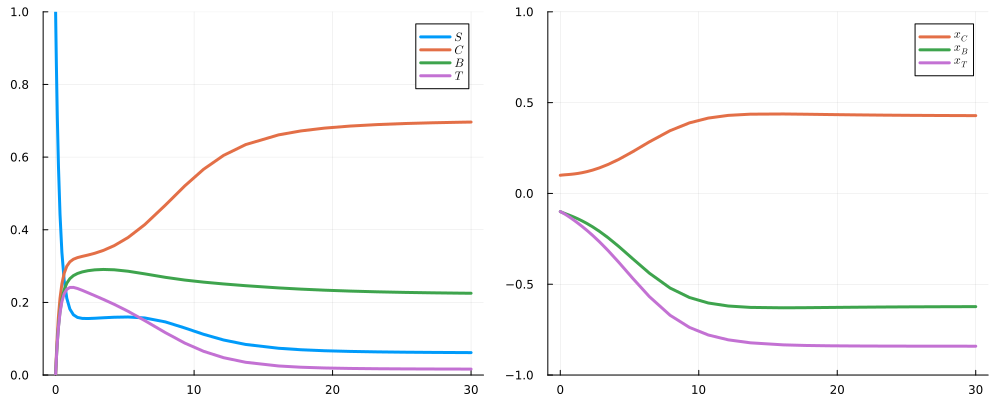

In [62]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.6,omegaB=0.5,k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.5,bB=-0.5,aCT=-0.2,aBT=0.5,bT=0.5)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT = par
u0 = [1.0,0,0,0.1,-0.1,-0.1]
tspan=(0.0,30.0)

prob_6d = ODEProblem(model_6d_t,u0,tspan,par)
sol6d = DifferentialEquations.solve(prob_6d)
S,C,T,xC,xB,xT = sol6d[1,:],sol6d[2,:],sol6d[3,:],sol6d[4,:],sol6d[5,:],sol6d[6,:]
B = 1 .- S .- C .- T

pal = palette(:default)

p1 = plot(sol6d.t, vec(S), label = L"S",  lw=3, ylims=(0,1), color = pal[1])
plot!(p1, sol6d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol6d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol6d.t, vec(T), label = L"T",   lw=3, color = pal[4])

p2 = plot(sol6d.t, vec(xC), label = L"x_C", lw=3, ylims=(-1,1), color = pal[2])
plot!(p2, sol6d.t, vec(xB), label = L"x_B", lw=3, color = pal[3])
plot!(p2, sol6d.t, vec(xT), label = L"x_T", lw=3, color = pal[4])

plot(p1, p2, size=(1000,400))

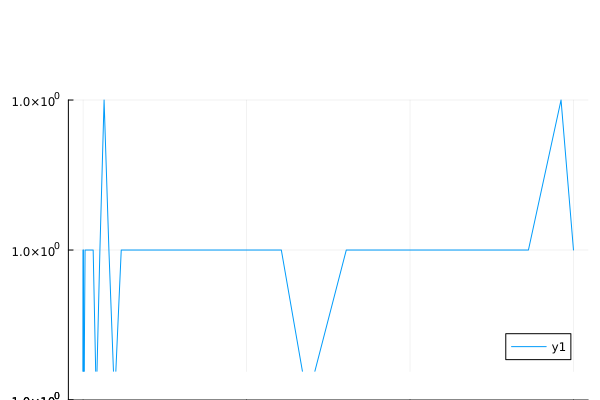

GKS: Possible loss of precision in routine SET_WINDOW


In [64]:
plot(sol6d.t,S .+ C .+ B .+ T)

In [20]:
1.75*0.5

0.875

In [21]:
(1-0.6)*0.5

0.2

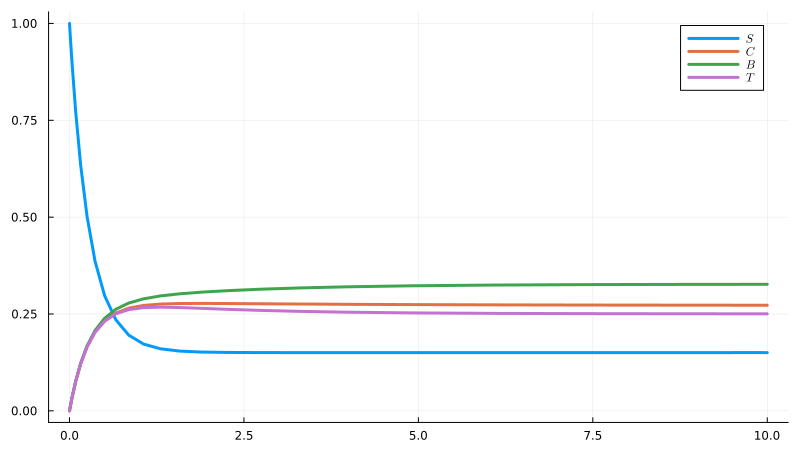

In [27]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.6,omegaB=0.5,k=0.5,n=4) # educated guesses for last 4
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n = par
u0 = [1.0,0,0]
tspan=(0.0,10.0)
prob_3d = ODEProblem(model_3d_t,u0,tspan,par)
sol = DifferentialEquations.solve(prob_3d)
S,C,T = sol[1,:],sol[2,:],sol[3,:]
B = 1 .- S .- C .- T

plot(sol.t, [S,C,B,T], label = [L"S" L"C" L"B" L"T"],linewidth = 3, size = (800,450))

In [ ]:
plot()

0.06179909859203411